# ICT-9 — Agence & regeneration : *reparer sa forme, ou seulement deriver ?*

> **Serie ICT** (Integrated Causal Trajectories, Epic #4588) — strate 2 : *morphogenese dynamique*.
> Prerequis conseilles : [ICT-0-Framing](ICT-0-Framing.md) et [ICT-8](ICT-8-AttractorLandscapesEWS.ipynb).

## La limite que ce notebook leve

La strate 1 (le tri auto-organise) et ICT-8 (les paysages d'attracteurs) butaient sur une limite : le
but du systeme etait **impose de l'exterieur** (le tableau trie ; le puits ou l'on tombe). Il n'y avait
**aucun point de consigne intrinseque** — rien que le systeme maintienne *de lui-meme*. ICT-9 leve
precisement cette limite avec un substrat **regenerant** : un systeme qui, apres qu'on a **detruit** une
partie de sa forme, la **reconstruit** vers la forme qu'il engendre spontanement.

## La question, et la regle du jeu

> **Quand peut-on dire qu'un systeme repare sa propre forme, au lieu de simplement evoluer passivement ?**

Reponse de la serie, *sans complaisance* : **l'agence n'est jamais declaree, elle est mesuree** — et
toujours **par contraste**. On ne credite un systeme d'agence sur sa forme que si sa trajectoire de
recuperation **domine quantitativement** celle d'un controle prive du mecanisme reparateur. Le mot-cle
est **contraste** : *reaction-diffusion* vs *diffusion simple*.

## Le cadre causal : deux mondes contrefactuels (Pearl)

C'est exactement le **calcul causal** de Judea Pearl. On applique une **intervention** identique —
`do(ablation)` : effacer un quart du motif — puis on compare **deux mondes** qui n'en different que par
la dynamique laissee a l'oeuvre :

| Monde | Dynamique apres `do(ablation)` | Prediction |
|---|---|---|
| **A** | reaction-diffusion complete | reconstruit la forme (regeneration) |
| **B** | diffusion pure (sans reaction) | dissout ce qui reste (passivite) |

La difference de recuperation entre A et B — le **gain de reparation** — *est* la mesure d'agence.
C'est le meme geste que le « sans liberte, pas d'agregation » d'ICT-4 et que « la mesure naive fabrique
un signal fantome » d'ICT-8 : une **competence n'est creditee qu'au vu d'un protocole explicite**.

## Le substrat : Gray-Scott (reaction-diffusion)

On utilise le systeme de **Gray-Scott** (J. E. Pearson, *Science* 1993), reference de la morphogenese de
Turing : deux especes qui diffusent et reagissent, engendrant spontanement des **taches** auto-entretenues.
C'est une *vraie* morphogenese generative — l'attracteur n'est pas une image figee mais un motif **vivant**
(les taches se divisent), ce qui aura des consequences sur *quelles mesures* sont honnetes (section 5).
Voir aussi Mordvintsev et al., *Growing Neural Cellular Automata* (Distill 2020), et les travaux de
M. Levin sur la regeneration et le « setpoint » morphologique.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath("."))
from ict.reaction_diffusion import GrayScott, run_pure_diffusion, pure_diffusion_step
from ict import agency

GRAINE = 8                 # reproductibilite
np.random.seed(GRAINE)

N = 96                     # cote de la grille (regime "taches" stable a cette echelle)
modele = GrayScott()       # F=0.0367, k=0.0649 : taches mitotiques de Pearson
print(f"Gray-Scott : F={modele.F}, k={modele.k}, Du={modele.Du}, Dv={modele.Dv}, dt={modele.dt}")
print(f"Grille {N}x{N}, bords periodiques.")

Gray-Scott : F=0.0367, k=0.0649, Du=0.16, Dv=0.08, dt=1.0
Grille 96x96, bords periodiques.


## 1. La morphogenese generative — un attracteur de forme

A partir d'un simple germe central, la reaction-diffusion **engendre** un motif spatial structure et
auto-entretenu. La quantite de structure est mesuree par la **variance spatiale** du champ d'activateur
$V$ : nulle pour un champ uniforme, positive des qu'un motif contraste apparait. Cette structure de
reference est le **point de consigne intrinseque** vers lequel le systeme pourra revenir.

**Precision.** Ce « point de consigne » n'est pas une memoire positionnelle pixel par pixel. Gray-Scott
ne retient pas *ou* etait chaque tache ; il retombe vers une **classe d'attracteur** — un *regime
morphologique* (taches de telle taille, telle densite, telle texture). « Reparer sa forme » signifie
ici *retrouver une organisation structuree du meme type*, pas reproduire l'image exacte. C'est
exactement pourquoi (section 5) les mesures de ressemblance pixel-a-pixel trompent, et pourquoi la
structure restauree — contrastee au controle passif — reste la seule mesure fiable.

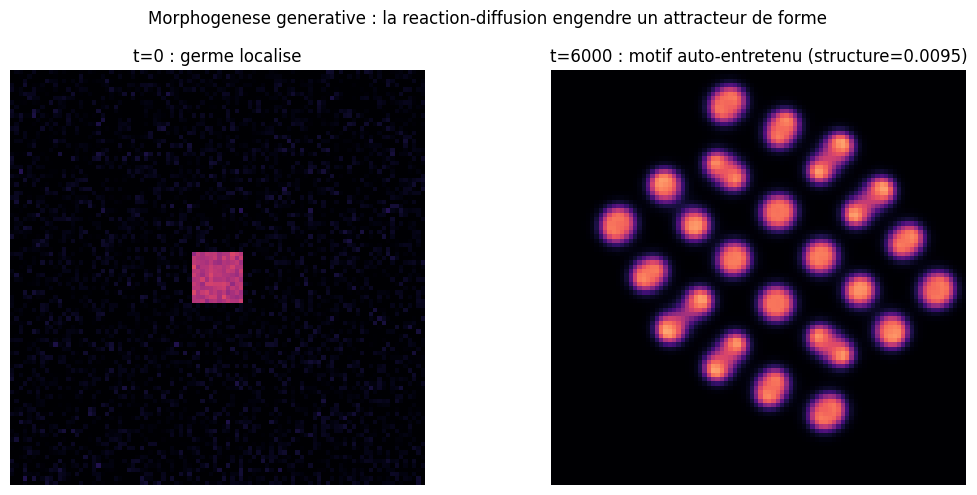

Structure (variance spatiale de V) du motif forme : 0.00950


In [2]:
rng = np.random.default_rng(GRAINE)
U0, V0 = modele.seed(n=N, rng=rng)
U_form, V_form, _ = modele.run(U0, V0, steps=6000)   # morphogenese
S_cible = agency.structure(V_form)                   # consigne intrinseque

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
a0.imshow(V0, cmap="magma", vmin=0, vmax=0.5); a0.set_title("t=0 : germe localise"); a0.axis("off")
a1.imshow(V_form, cmap="magma", vmin=0, vmax=0.5)
a1.set_title(f"t=6000 : motif auto-entretenu (structure={S_cible:.4f})"); a1.axis("off")
plt.suptitle("Morphogenese generative : la reaction-diffusion engendre un attracteur de forme")
plt.tight_layout(); plt.show()
print(f"Structure (variance spatiale de V) du motif forme : {S_cible:.5f}")

## 2. L'ablation comme intervention `do(.)`

On **detruit** un quart du motif en le ramenant a l'etat nu du substrat ($U=1$, $V=0$ : « pas de motif
ici »). Au sens de Pearl, c'est une **intervention** `do(ablation)` : on force une partie de l'etat, puis
on observe la trajectoire qui en decoule. La question d'agence devient : *que se passe-t-il ensuite ?*

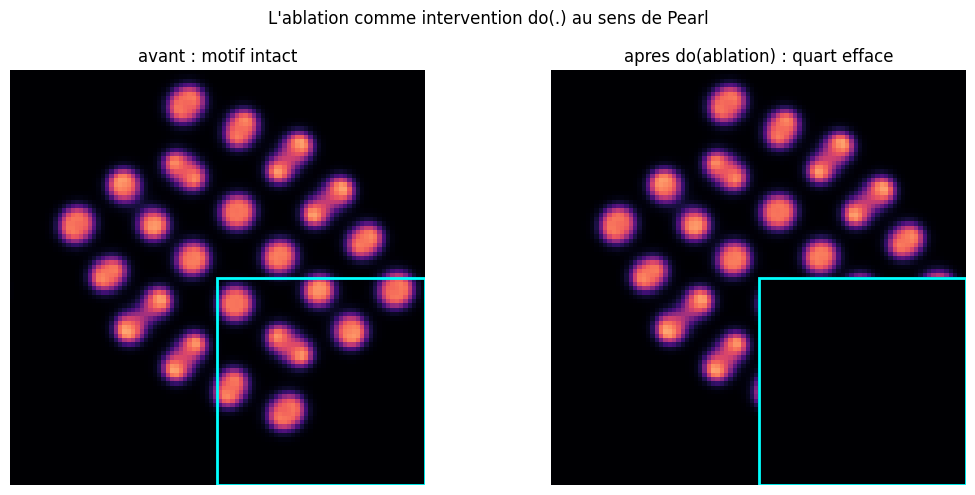

Structure dans le quart ablate : 0.000000  (~0 : motif efface)


In [3]:
mask = agency.quadrant_mask(N, quadrant=3)            # quart bas-droit
U_abl, V_abl = agency.ablate(U_form, V_form, mask)   # do(ablation)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
a0.imshow(V_form, cmap="magma", vmin=0, vmax=0.5); a0.set_title("avant : motif intact"); a0.axis("off")
a1.imshow(V_abl, cmap="magma", vmin=0, vmax=0.5); a1.set_title("apres do(ablation) : quart efface"); a1.axis("off")
for ax in (a0, a1):
    ax.add_patch(mpatches.Rectangle((N//2 - 0.5, N//2 - 0.5), N//2, N//2, fill=False, ec="cyan", lw=2))
plt.suptitle("L'ablation comme intervention do(.) au sens de Pearl")
plt.tight_layout(); plt.show()
print(f"Structure dans le quart ablate : {agency.structure(V_abl[mask]):.6f}  (~0 : motif efface)")

### Exercice 1 — quantifier le dommage

Avant de mesurer une *reparation*, il faut mesurer le *dommage*. Completez `dommage_inflige` : la perte
de structure (variance regionale) dans la zone ablatee. *Fil de la mesure* : c'est la grandeur que la
reparation devra regagner.

*Indices :* `agency.structure(champ)` calcule la variance ; `V[mask]` selectionne la zone ; comparer
la structure regionale avant et apres ablation.

In [4]:
def dommage_inflige(V_reference, V_ablate, mask):
    """Perte de structure dans la zone ablatee : structure(reference|zone) - structure(ablate|zone).
    Renvoyer None tant que l'exercice n'est pas complete."""
    # TODO etudiant : comparer la variance regionale avant / apres l'ablation
    # s_avant = agency.structure(V_reference[mask])
    # s_apres = agency.structure(V_ablate[mask])
    # return float(s_avant - s_apres)
    return None  # TODO

# Verification (a decommenter une fois l'exercice complete) :
# print("dommage inflige :", dommage_inflige(V_form, V_abl, mask))
print("Exercice 1 a completer : quantifier le motif detruit par l'ablation.")

Exercice 1 a completer : quantifier le motif detruit par l'ablation.


## 3. Deux mondes contrefactuels : reaction-diffusion vs diffusion pure

Depuis **le meme** etat ablate, on laisse evoluer deux dynamiques. Le **monde A** garde la reaction-
diffusion complete ; le **monde B** ne garde que la diffusion (meme operateur diffusif, terme reactif
retire) — le **controle passif**. On enregistre la trajectoire de structure *dans la zone ablatee* pour
les deux mondes, afin de comparer non seulement l'etat final mais toute la dynamique de recuperation.

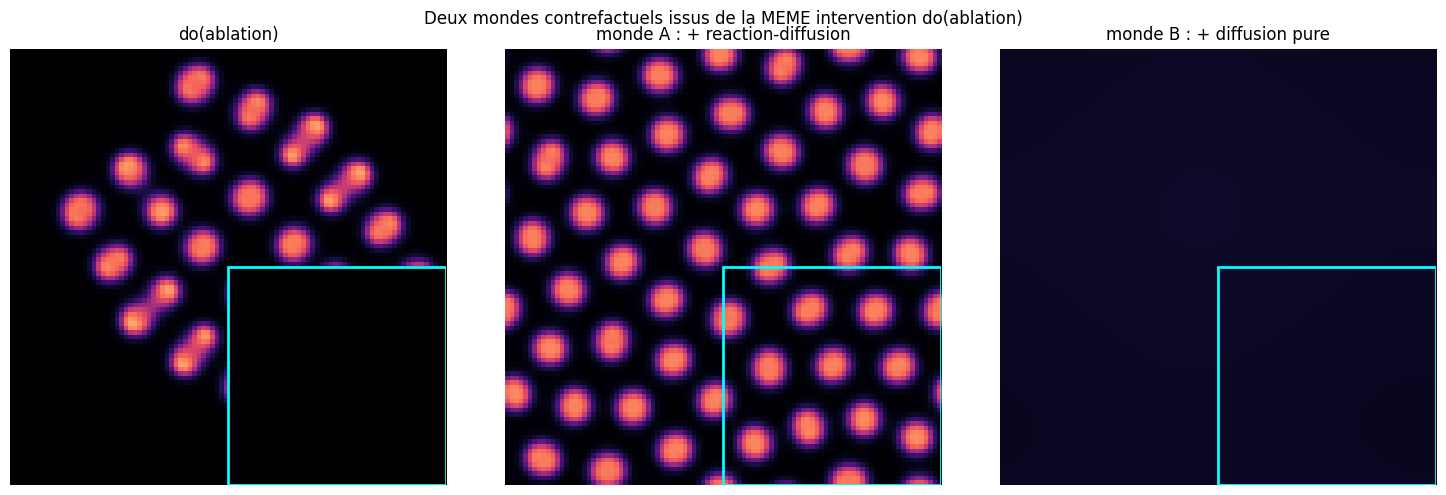

structure zone (fin) : monde A = 0.01330 | monde B = 0.00000


In [5]:
REPAIR_STEPS = 8000
REC_EVERY = 200

# --- Monde A : do(ablation) + reaction-diffusion (mecanisme reparateur complet) ---
# La trajectoire est ancree a l'instant 0 (etat ablate exact), comme le ferait
# modele.run(..., record_every=REC_EVERY, include_initial=True) pour les champs.
U_rd, V_rd = U_abl.copy(), V_abl.copy()
traj_rd = [agency.structure(V_rd[mask])]          # t = 0 : etat ablate
for t in range(REPAIR_STEPS):
    U_rd, V_rd = modele.step(U_rd, V_rd)
    if (t + 1) % REC_EVERY == 0:
        traj_rd.append(agency.structure(V_rd[mask]))

# --- Monde B : do(ablation) + diffusion pure (controle passif, sans reaction) ---
V_diff = V_abl.copy()
traj_diff = [agency.structure(V_diff[mask])]      # t = 0 : etat ablate
for t in range(REPAIR_STEPS):
    V_diff = pure_diffusion_step(V_diff, modele.Dv)
    if (t + 1) % REC_EVERY == 0:
        traj_diff.append(agency.structure(V_diff[mask]))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panneaux = [(V_abl, "do(ablation)"), (V_rd, "monde A : + reaction-diffusion"),
            (V_diff, "monde B : + diffusion pure")]
for ax, (img, ttl) in zip(axes, panneaux):
    ax.imshow(img, cmap="magma", vmin=0, vmax=0.5); ax.set_title(ttl); ax.axis("off")
    ax.add_patch(mpatches.Rectangle((N//2 - 0.5, N//2 - 0.5), N//2, N//2, fill=False, ec="cyan", lw=2))
plt.suptitle("Deux mondes contrefactuels issus de la MEME intervention do(ablation)")
plt.tight_layout(); plt.show()
print(f"structure zone (fin) : monde A = {agency.structure(V_rd[mask]):.5f} | monde B = {agency.structure(V_diff[mask]):.5f}")

## 4. L'agence mesuree : le gain de reparation

Le **score de recuperation** rapporte la structure regagnee dans la zone a la structure perdue ($\approx 1$
= zone integralement reconstituee, $\approx 0$ = rien ne repousse). Le **gain de reparation** est la
difference entre les deux mondes :

$$\text{gain} = \text{recuperation}_{\text{reaction-diffusion}} - \text{recuperation}_{\text{diffusion}}$$

Strictement positif et substantiel, il signe une trajectoire qui *repare activement*. C'est la mesure
d'agence — et le **temps de recuperation** dit *a quelle vitesse* la forme revient vers sa consigne.

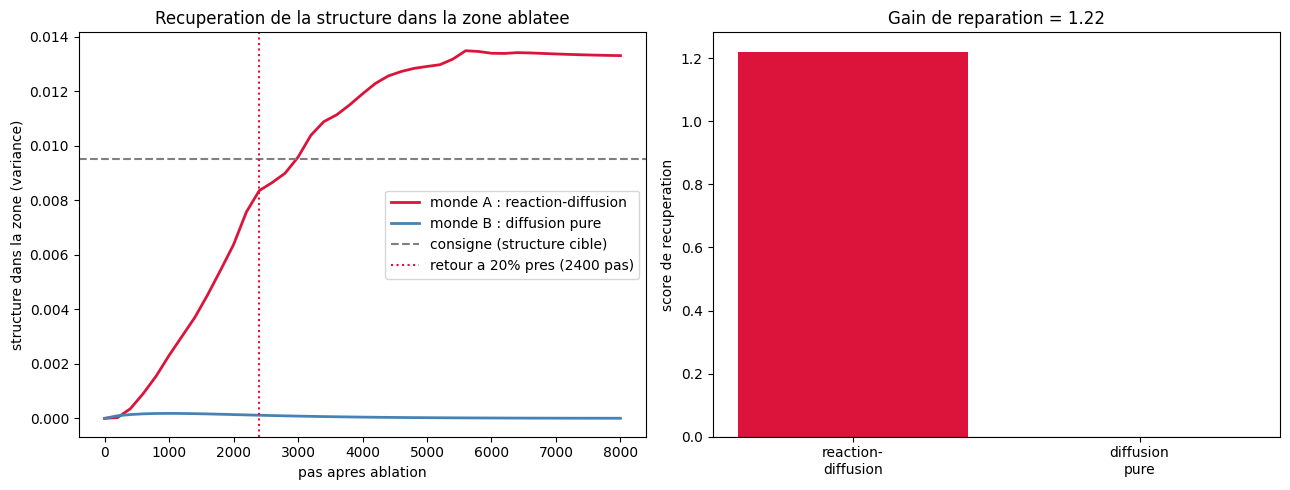

recuperation A (RD) = 1.22 | recuperation B (diffusion) = 0.00 | GAIN = 1.22
temps de recuperation (monde A, a 20% pres) = 2400 pas


In [6]:
rec_rd   = agency.recovery_score(V_form, V_abl, V_rd, mask)
rec_diff = agency.recovery_score(V_form, V_abl, V_diff, mask)
gain     = agency.repair_gain(rec_rd, rec_diff)
ttr      = agency.time_to_recover(traj_rd, S_cible, tol=0.2, record_every=REC_EVERY)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
ts = np.arange(len(traj_rd)) * REC_EVERY
axL.plot(ts, traj_rd, color="crimson", lw=2, label="monde A : reaction-diffusion")
axL.plot(ts, traj_diff, color="steelblue", lw=2, label="monde B : diffusion pure")
axL.axhline(S_cible, ls="--", color="grey", label="consigne (structure cible)")
if ttr is not None:
    axL.axvline(ttr, ls=":", color="crimson", label=f"retour a 20% pres ({ttr} pas)")
axL.set_xlabel("pas apres ablation"); axL.set_ylabel("structure dans la zone (variance)")
axL.set_title("Recuperation de la structure dans la zone ablatee"); axL.legend()

axR.bar(["reaction-\ndiffusion", "diffusion\npure"], [rec_rd, rec_diff], color=["crimson", "steelblue"])
axR.axhline(0, color="black", lw=0.8); axR.set_ylabel("score de recuperation")
axR.set_title(f"Gain de reparation = {gain:.2f}")
plt.tight_layout(); plt.show()

print(f"recuperation A (RD) = {rec_rd:.2f} | recuperation B (diffusion) = {rec_diff:.2f} | GAIN = {gain:.2f}")
print(f"temps de recuperation (monde A, a 20% pres) = {ttr} pas")

### Exercice 2 — l'agence est-elle locale ou generale ?

On a mesure la reparation d'**un** quart. Une vraie regeneration devrait reparer **n'importe quelle**
zone. Completez `gain_reparation_ailleurs(quadrant)` pour ablater puis mesurer le gain sur un autre
quadrant, et verifiez que l'agence n'est pas un artefact de l'endroit choisi.

*Indices :* reproduire la logique des sections 3-4 en changeant le masque ; `pure_diffusion_step(champ, modele.Dv)`
pour le controle passif ; `agency.recovery_score(...)` puis `agency.repair_gain(...)`.

In [7]:
def gain_reparation_ailleurs(quadrant):
    """Ablate un AUTRE quadrant puis renvoie le gain de reparation (RD vs diffusion) pour cette zone.
    Teste si l'agence est locale a une zone ou generale. Renvoyer None tant que non complete."""
    # TODO etudiant :
    # m = agency.quadrant_mask(N, quadrant)
    # Ua, Va = agency.ablate(U_form, V_form, m)
    # _, Vr, _ = modele.run(Ua.copy(), Va.copy(), steps=REPAIR_STEPS)
    # Vd = Va.copy()
    # for _ in range(REPAIR_STEPS):
    #     Vd = pure_diffusion_step(Vd, modele.Dv)
    # rec_a = agency.recovery_score(V_form, Va, Vr, m)
    # rec_b = agency.recovery_score(V_form, Va, Vd, m)
    # return agency.repair_gain(rec_a, rec_b)
    return None  # TODO

# Verification (a decommenter) :
# for q in range(4):
#     print(f"quadrant {q} : gain = {gain_reparation_ailleurs(q)}")
print("Exercice 2 a completer : l'agence repare-t-elle aussi bien partout ?")

Exercice 2 a completer : l'agence repare-t-elle aussi bien partout ?


## 5. *Sans complaisance* : la ressemblance trompe, le contraste tient

La tentation serait de juger la reparation par la **ressemblance a l'image d'origine**. Deux mesures
naives le proposent — et **toutes deux trompent** :

- **distance pixel a pixel** : elle *penalise* la reaction-diffusion, parce qu'un attracteur **mitotique**
  (les taches se divisent et migrent) ne revient *jamais* au pixel pres. La bonne question n'est pas
  « est-ce la meme image ? » mais « est-ce un motif du **meme type** ? ».
- **similarite spectrale (cosinus)** : elle peut attribuer un score *eleve* a la zone simplement diffusee...
  qui n'a pourtant **aucune structure**. Le cosinus normalise l'amplitude : il fabrique une **ressemblance
  fantome** sur un champ quasi vide — exactement le piege « mesure naive = signal fantome » d'ICT-8.

La seule mesure fiable est celle qu'on a retenue : **la structure restauree, contrastee au controle
passif**. L'agence se mesure comme *restauration sous intervention*, pas comme *ressemblance a un gabarit
fige*.

In [8]:
def crop(field):
    h = N // 2
    return field[h:N, h:N]            # la zone ablatee (quart bas-droit)

dist_pix_rd   = agency.pattern_distance(crop(V_form), crop(V_rd))
dist_pix_diff = agency.pattern_distance(crop(V_form), crop(V_diff))
spec_rd   = agency.spectral_similarity(crop(V_form), crop(V_rd))
spec_diff = agency.spectral_similarity(crop(V_form), crop(V_diff))
pow_rd    = agency.structure(crop(V_rd))
pow_diff  = agency.structure(crop(V_diff))
seuil_energie = 0.1 * S_cible          # garde-fou : 10% de la structure de reference
spec_rd_g   = agency.energy_gated_spectral_similarity(crop(V_form), crop(V_rd),   min_variance=seuil_energie)
spec_diff_g = agency.energy_gated_spectral_similarity(crop(V_form), crop(V_diff), min_variance=seuil_energie)

print("Mesure naive 1 -- ressemblance PIXEL A PIXEL (plus petit = plus ressemblant) :")
print(f"   RD = {dist_pix_rd:.4f}   |   diffusion = {dist_pix_diff:.4f}")
print("   -> la diffusion semble parfois 'plus proche' : PIEGE. Un attracteur mitotique ne")
print("      revient jamais au pixel pres ; la RD a reconstruit un motif vivant, donc deplace.")
print()
print("Mesure naive 2 -- similarite SPECTRALE cosinus (plus grand = texture plus proche) :")
print(f"   RD = {spec_rd:.3f}  (structure zone = {pow_rd:.5f})")
print(f"   diffusion = {spec_diff:.3f}  (structure zone = {pow_diff:.5f})")
print("   -> un cosinus eleve sur une zone SANS structure (~0) est une ressemblance FANTOME :")
print("      le cosinus ignore l'amplitude. Sans structure, il n'y a rien a 'ressembler'.")
print()
print(f"Garde-fou -- similarite spectrale PROTEGEE PAR L'ENERGIE (seuil = {seuil_energie:.5f}) :")
print(f"   RD = {spec_rd_g:.3f}   |   diffusion = {spec_diff_g:.3f}")
print("   -> la zone diffusee tombe SOUS le seuil : la ressemblance fantome est annulee (0).")
print()
print(f"Seule mesure fiable : structure restauree contrastee au controle passif -> GAIN = {gain:.2f}")

Mesure naive 1 -- ressemblance PIXEL A PIXEL (plus petit = plus ressemblant) :
   RD = 0.1688   |   diffusion = 0.1063
   -> la diffusion semble parfois 'plus proche' : PIEGE. Un attracteur mitotique ne
      revient jamais au pixel pres ; la RD a reconstruit un motif vivant, donc deplace.

Mesure naive 2 -- similarite SPECTRALE cosinus (plus grand = texture plus proche) :
   RD = 0.631  (structure zone = 0.01330)
   diffusion = 0.735  (structure zone = 0.00000)
   -> un cosinus eleve sur une zone SANS structure (~0) est une ressemblance FANTOME :
      le cosinus ignore l'amplitude. Sans structure, il n'y a rien a 'ressembler'.

Garde-fou -- similarite spectrale PROTEGEE PAR L'ENERGIE (seuil = 0.00095) :
   RD = 0.631   |   diffusion = 0.000
   -> la zone diffusee tombe SOUS le seuil : la ressemblance fantome est annulee (0).

Seule mesure fiable : structure restauree contrastee au controle passif -> GAIN = 1.22


## 6. Le controle « bruit apparie en variance » — la variance ne suffit pas

La mesure de structure est la **variance spatiale** : simple et honnete pour dire « il y a de l'energie
ici ». Mais l'energie n'est pas l'organisation. Un champ de **bruit blanc** peut avoir *exactement la
meme variance* qu'un motif repare tout en n'ayant **aucune** structure spatiale.

On construit donc un controle adverse : un bruit apparie en moyenne et variance a la zone reparee. S'il
obtient le meme score de `structure`, c'est que la variance seule ne certifie pas une forme — il faut
une mesure d'**organisation**. L'auto-correlation spatiale au decalage 1 (`spatial_autocorrelation`) joue
ce role : proche de 1 pour un champ lisse et organise, proche de 0 pour du bruit. Elle confirme que la
variance regagnee par la reaction-diffusion est une **vraie forme**, pas du bruit de meme energie.


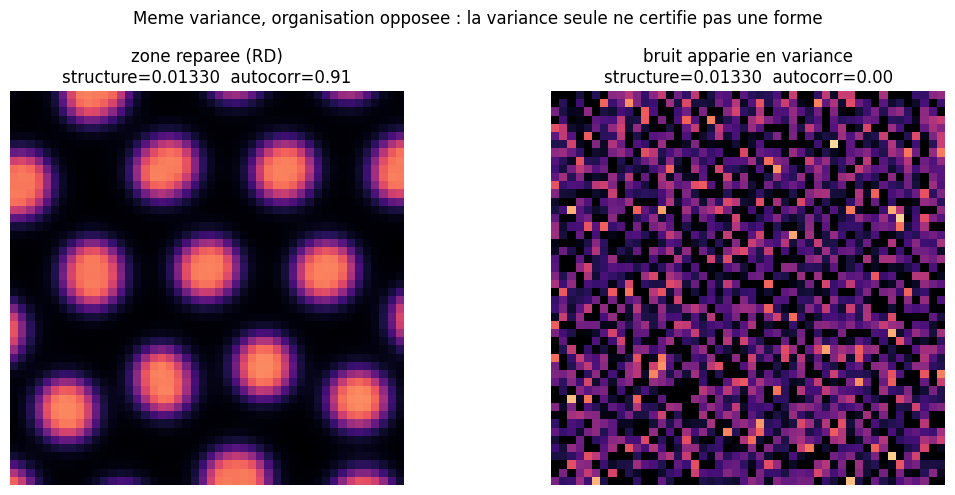

structure (variance)      : RD = 0.01330  |  bruit apparie = 0.01330   (~ identiques)
auto-correlation spatiale : RD = 0.91     |  bruit apparie = 0.00      (le discriminant)
-> la variance regagnee par la RD est une VRAIE forme (voisins correles), pas du bruit de meme energie.


In [9]:
rng_ctrl = np.random.default_rng(GRAINE)
zone_rd = crop(V_rd)                                       # la zone reparee par reaction-diffusion
bruit   = agency.variance_matched_noise(zone_rd, rng_ctrl)  # meme moyenne/variance, aucune organisation

s_rd,  s_bruit  = agency.structure(zone_rd), agency.structure(bruit)
ac_rd, ac_bruit = agency.spatial_autocorrelation(zone_rd), agency.spatial_autocorrelation(bruit)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
a0.imshow(zone_rd, cmap="magma", vmin=0, vmax=0.5)
a0.set_title(f"zone reparee (RD)\nstructure={s_rd:.5f}  autocorr={ac_rd:.2f}"); a0.axis("off")
a1.imshow(bruit, cmap="magma", vmin=0, vmax=0.5)
a1.set_title(f"bruit apparie en variance\nstructure={s_bruit:.5f}  autocorr={ac_bruit:.2f}"); a1.axis("off")
plt.suptitle("Meme variance, organisation opposee : la variance seule ne certifie pas une forme")
plt.tight_layout(); plt.show()

print(f"structure (variance)      : RD = {s_rd:.5f}  |  bruit apparie = {s_bruit:.5f}   (~ identiques)")
print(f"auto-correlation spatiale : RD = {ac_rd:.2f}     |  bruit apparie = {ac_bruit:.2f}      (le discriminant)")
print("-> la variance regagnee par la RD est une VRAIE forme (voisins correles), pas du bruit de meme energie.")


### Exercice 3 — robustesse : la probabilite de retour au bassin

Mesure plus exigeante : sur plusieurs ablations **aleatoires**, quelle fraction revient a la consigne ?
Completez `proba_retour_bassin`. *Avertissement d'honnetete* : chaque essai est une simulation complete
(c'est **couteux**) et le resultat est **stochastique** — a petit nombre d'essais, l'estimation a une
forte variance. Documentez cette limite plutot que de sur-interpreter le chiffre.

*Indices :* `agency.basin_return_probability(modele, U_form, V_form, make_mask, steps, target_structure, ...)` ;
`make_mask(rng)` doit renvoyer un `agency.disk_mask(N, cx, cy, rayon)` de centre aleatoire.

In [10]:
def proba_retour_bassin(n_essais=5, rayon=14):
    """Fraction d'ablations aleatoires (disques) dont la structure finale revient a la cible.
    Renvoyer None tant que non complete.
    ATTENTION : couteux (chaque essai = une simulation complete) et stochastique (forte variance
    a petit n_essais) -- ne pas sur-interpreter une statistique a petit echantillon."""
    # TODO etudiant :
    # def make_mask(rng):
    #     cx, cy = rng.integers(0, N, size=2)
    #     return agency.disk_mask(N, cx, cy, rayon)
    # return agency.basin_return_probability(
    #     modele, U_form, V_form, make_mask,
    #     steps=REPAIR_STEPS, target_structure=S_cible, tol=0.3,
    #     n_trials=n_essais, rng=np.random.default_rng(GRAINE))
    return None  # TODO

# Verification (a decommenter -- patienter, c'est plusieurs simulations completes) :
# print("proba de retour au bassin :", proba_retour_bassin(n_essais=5))
print("Exercice 3 a completer : robustesse de l'agence sous ablations aleatoires (mesure couteuse).")

Exercice 3 a completer : robustesse de l'agence sous ablations aleatoires (mesure couteuse).


## 7. Au-dela du cas unique : un balayage de robustesse

Une seule demonstration ne fait pas une loi. On repete donc la mesure d'agence sur un petit **balayage** :
plusieurs graines (motifs differents), plusieurs **tailles** et **formes** d'ablation (quadrant, disques
de rayons varies). Le balayage est volontairement **borne** (3 graines x 3 masques) pour rester dans un
temps de calcul raisonnable — il vise a sortir du cas unique, pas a etre exhaustif. Le critere : le gain
de reparation reste-t-il **positif** sur l'ensemble des conditions ?


 graine      masque   rec_RD  rec_diff    gain
      1    quadrant     1.71      0.00    1.71
      1  disque r12     1.52      0.00    1.52
      1  disque r20     0.97      0.00    0.97
      7    quadrant     1.46      0.00    1.46
      7  disque r12     0.83      0.00    0.83
      7  disque r20     0.97      0.00    0.97
     42    quadrant     1.57      0.00    1.56
     42  disque r12     1.33      0.00    1.33
     42  disque r20     0.99      0.00    0.99

gain de reparation : moyenne=1.26  min=0.83  max=1.71
positif sur 9/9 conditions (graines x masques) -> l'agence n'est pas un artefact d'un cas unique.


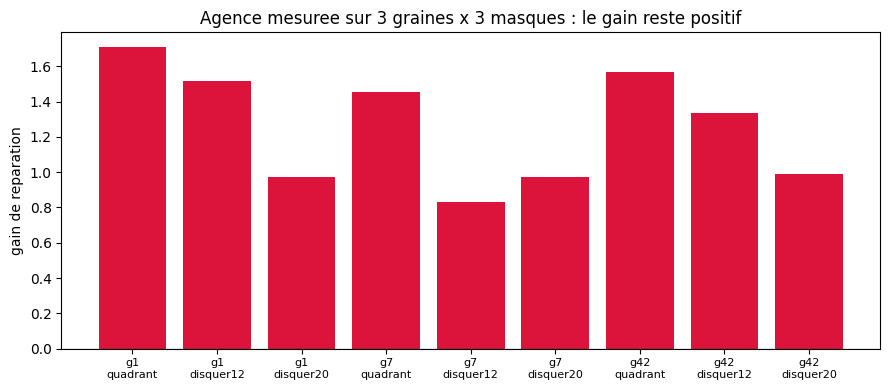

In [11]:
FORM_S, REPAIR_S = 5000, 5000
graines_sweep = [1, 7, 42]

def masques_sweep(n):
    return [("quadrant",   agency.quadrant_mask(n, 3)),
            ("disque r12",  agency.disk_mask(n, 0.70 * n, 0.30 * n, 12)),
            ("disque r20",  agency.disk_mask(n, 0.35 * n, 0.65 * n, 20))]

lignes, gains = [], []
for g in graines_sweep:
    Ug, Vg = modele.seed(n=N, rng=np.random.default_rng(g))
    Uf, Vf, _ = modele.run(Ug, Vg, steps=FORM_S)               # forme un motif (graine g)
    for nom, m in masques_sweep(N):
        Ua, Va = agency.ablate(Uf, Vf, m)                      # do(ablation)
        _, V_rd_s, _ = modele.run(Ua.copy(), Va.copy(), steps=REPAIR_S)        # monde RD
        V_diff_s = run_pure_diffusion(Va.copy(), modele.Dv, steps=REPAIR_S)    # monde diffusion
        r_rd   = agency.recovery_score(Vf, Va, V_rd_s,   m)
        r_diff = agency.recovery_score(Vf, Va, V_diff_s, m)
        gn = agency.repair_gain(r_rd, r_diff)
        lignes.append((g, nom, r_rd, r_diff, gn)); gains.append(gn)

gains = np.array(gains)
print(f"{'graine':>7} {'masque':>11} {'rec_RD':>8} {'rec_diff':>9} {'gain':>7}")
for (g, nom, r_rd, r_diff, gn) in lignes:
    print(f"{g:>7} {nom:>11} {r_rd:>8.2f} {r_diff:>9.2f} {gn:>7.2f}")
n_pos = int((gains > 0).sum())
print(f"\ngain de reparation : moyenne={gains.mean():.2f}  min={gains.min():.2f}  max={gains.max():.2f}")
print(f"positif sur {n_pos}/{len(gains)} conditions (graines x masques) -> l'agence n'est pas un artefact d'un cas unique.")

fig, ax = plt.subplots(figsize=(9, 4))
etq = [f"g{g}\n{nom.replace(' ', '')}" for (g, nom, _, _, _) in lignes]
ax.bar(range(len(gains)), gains, color=["crimson" if x > 0 else "grey" for x in gains])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(gains))); ax.set_xticklabels(etq, fontsize=8)
ax.set_ylabel("gain de reparation")
ax.set_title("Agence mesuree sur 3 graines x 3 masques : le gain reste positif")
plt.tight_layout(); plt.show()


## 8. Pont vers la suite : ICT-10/11/12 et la synthese

ICT-9 a ajoute la piece manquante du marche-pied : un **point de consigne intrinseque**, defendu
activement. La feuille de route de la strate 2 poursuit, **chaque metaphore restant attachee a une
mesure** :

- **ICT-10 — Grammaire des catastrophes** : typer les transitions qualitatives (pli, fronce, fourche,
  hysteresis) — la *catastrophe* comme **transition mesuree**, pas comme image.
- **ICT-11 — Profils d'agence causale** : l'agence aux echelles micro / meso / macro (lien avec la
  causal emergence d'[ICT-5](ICT-5-CausalEmergence.ipynb) / [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb)).
- **ICT-12 — Renormalisation causale & signatures fractales** : l'**invariance multi-echelle** des
  proprietes causales — le *fractal* comme **invariance testee**, pas comme jolie image.
- **ICT-Synthese** : reunir $\Phi$, trajectoires, bassins, transitions, reparation, emergence,
  invariance d'echelle et agence en un seul fil.

Discipline de la serie : *ne pas ouvrir cinq fronts a la fois* — une metaphore n'entre dans ICT que
lorsqu'elle est **attachee a une mesure**.

*Cette passe ICT-9.1 a consolide la base de mesure — similarite spectrale protegee par l'energie
(section 5), controle « bruit apparie en variance » (section 6), balayage graines x tailles x formes
(section 7) — avant d'etendre. Elle fige la grammaire commune* dynamique -> intervention do(.) ->
controle passif -> recuperation -> profil multi-echelle -> test d'invariance *sur laquelle ICT-11
(profils d'agence multi-echelle) et ICT-12 (renormalisation) s'appuieront.*

## Conclusion — l'agence tenue par la mesure

On a tresse les deux fils jusqu'au bout :

| Le fil metaphorique | Le fil de la mesure |
|---|---|
| un organisme « repare sa blessure » | la structure regionale (variance) regagnee apres ablation |
| il « veut » retrouver sa forme | une consigne **intrinseque** : le motif qu'il engendre spontanement |
| la guerison est *active* | gain = recuperation(reaction-diffusion) - recuperation(diffusion) > 0 |
| « ca ressemble a avant » | **piege** : pixel-a-pixel et cosinus fabriquent l'illusion ; seule la structure+contraste tient |
| deux destins possibles | deux mondes contrefactuels issus du meme `do(ablation)` (Pearl) |
| « le cosinus dit que ca ressemble » | **garde-fou** : la similarite spectrale *protegee par l'energie* annule la ressemblance fantome |
| « il y a de la variance, donc une forme » | **controle** : un bruit *apparie en variance* a le meme score ; l'auto-correlation tranche |
| « un cas, donc une loi » | un **balayage** graines x tailles x formes : le gain reste positif hors du cas unique |

**L'agence n'a pas ete declaree : elle a ete mesuree** — comme un *gain de recuperation* sur un controle
passif, sur un vrai systeme de reaction-diffusion. C'est la traduction morphogenetique de la these de la
serie : une competence (« maintenir sa propre forme ») n'est creditee qu'au vu de ce qu'une experience
explicite, et contrastee, en montre. La strate 2 tient desormais son **point de consigne intrinseque** ;
reste a en typer les transitions (ICT-10) et a en mesurer les echelles (ICT-11/12).